# Exploratory Data Analysis (EDA)

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Make plots look nicer
plt.rcParams['figure.figsize'] = (10, 6)

Original shape: (9564, 153)
Class Balance:


koi_disposition
FALSE POSITIVE    4839
CONFIRMED         2747
CANDIDATE         1978
Name: count, dtype: int64

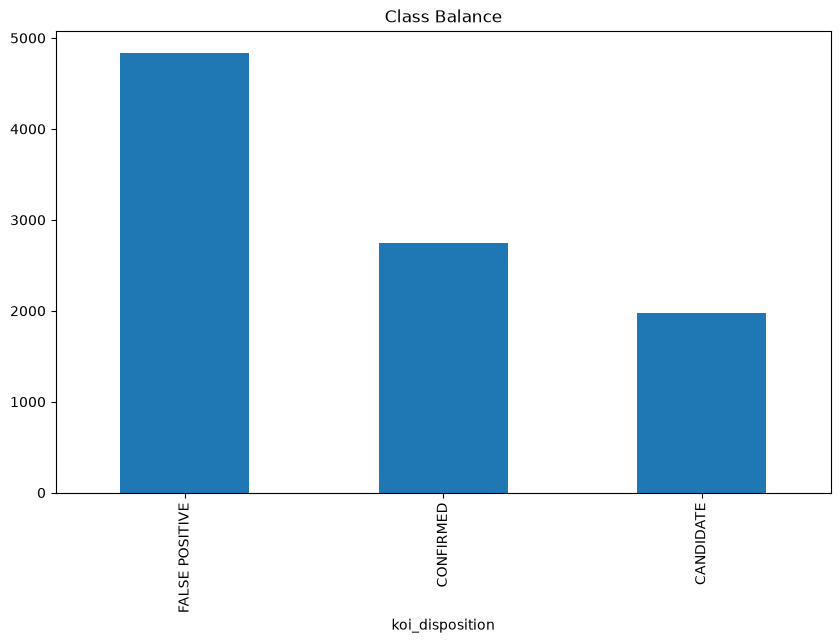

In [ ]:
# 1. Load Data
df = pd.read_csv('../data/cumulative.csv')
print(f"Original shape: {df.shape}")

# Show class balance
print("Class Balance:")
display(df['koi_disposition'].value_counts())
df['koi_disposition'].value_counts().plot(kind='bar', title='Class Balance')
plt.show()

In [3]:
# 2. Drop columns that are IDs, error columns (ending in _err1, _err2, _err), or >50% missing

# Identify error/uncertainty columns
error_cols = [c for c in df.columns if c.endswith('_err1') or c.endswith('_err2') or c.endswith('_err')]
df = df.drop(columns=error_cols)

# Identify ID/string columns to drop
id_cols = ['kepid', 'kepoi_name', 'kepler_name', 'koi_tce_delivname']
df = df.drop(columns=[c for c in id_cols if c in df.columns], errors='ignore')

# Drop columns with > 50% missing values
missing_frac = df.isnull().mean()
high_missing_cols = missing_frac[missing_frac > 0.5].index
df = df.drop(columns=high_missing_cols)

print(f"Shape after dropping columns: {df.shape}")

Shape after dropping columns: (9564, 76)


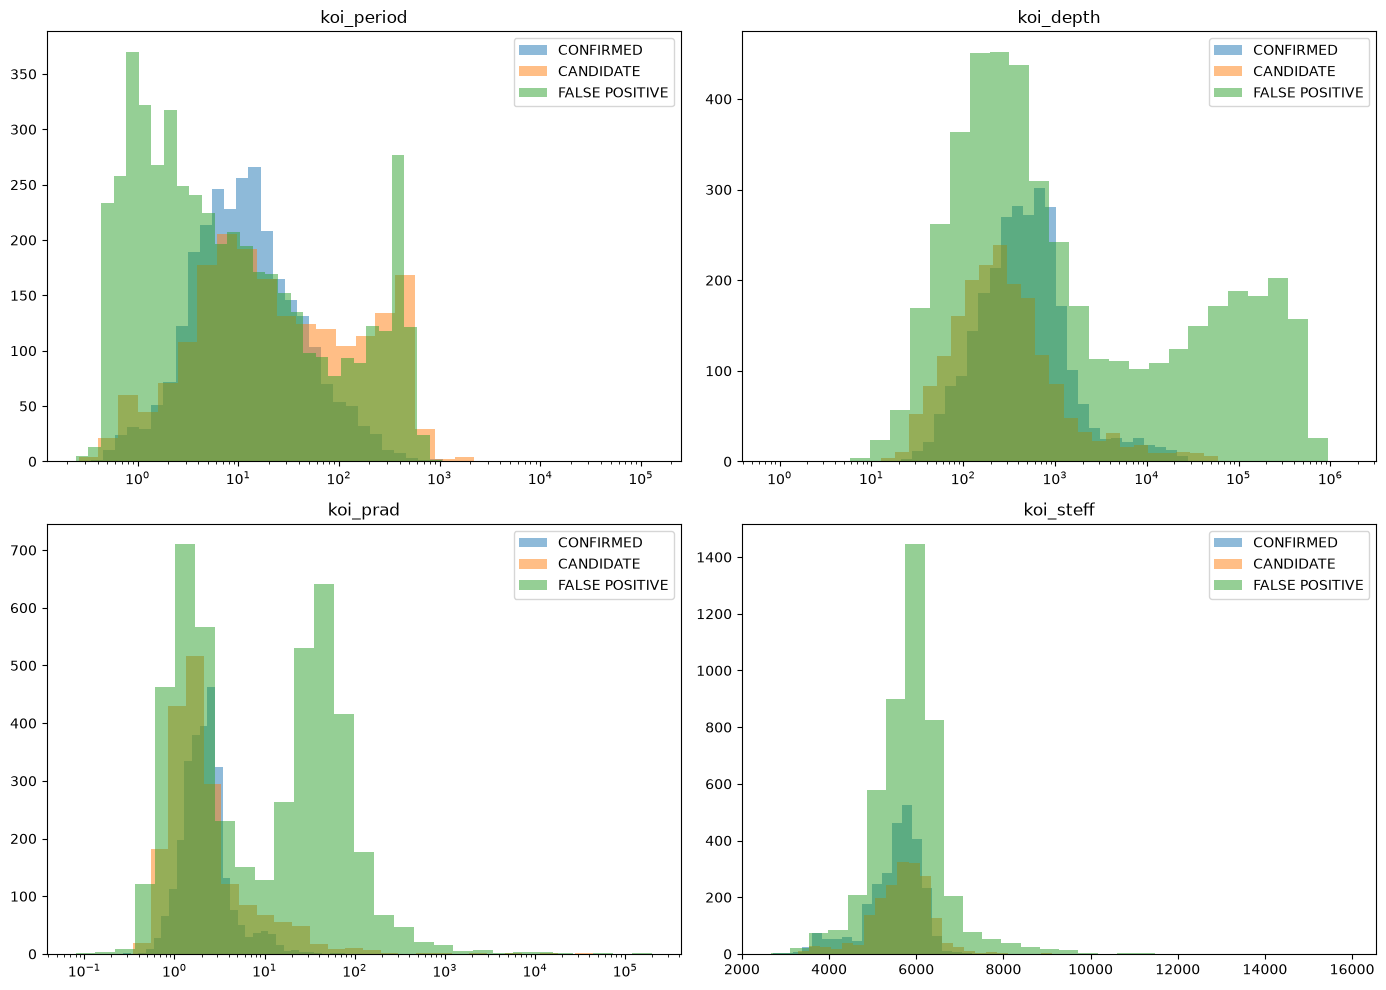

In [4]:
# 3. Plot 3-4 key features split by class
# Features: koi_period (Orbital Period), koi_depth (Transit Depth), koi_prad (Planet Radius), koi_steff (Stellar Temp)
features_to_plot = ['koi_period', 'koi_depth', 'koi_prad', 'koi_steff']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, feature in enumerate(features_to_plot):
    if feature in df.columns:
        # Determine if we should use a log scale (useful for highly skewed features)
        use_log = feature in ['koi_period', 'koi_depth', 'koi_prad']
        
        # Plot histograms for each class
        for disposition in df['koi_disposition'].dropna().unique():
            subset = df[df['koi_disposition'] == disposition][feature].dropna()
            
            # Using log scale bins if use_log is true to make histograms look better
            if use_log and (subset > 0).any():
                min_val = subset[subset > 0].min()
                max_val = subset.max()
                # add small epsilon to min_val if it's 0 somehow
                if min_val <= 0: min_val = 1e-5
                bins = np.logspace(np.log10(min_val), np.log10(max_val), 30)
                axes[i].hist(subset, bins=bins, alpha=0.5, label=disposition)
                axes[i].set_xscale('log')
            else:
                axes[i].hist(subset, bins=30, alpha=0.5, label=disposition)
                
        axes[i].set_title(feature)
        axes[i].legend()

plt.tight_layout()
plt.show()

In [5]:
# 4. Save cleaned dataframe
cleaned_path = '../data/cleaned.csv'
df.to_csv(cleaned_path, index=False)
print(f"Cleaned dataset saved to {cleaned_path}")

Cleaned dataset saved to ../data/cleaned.csv
